# Auditoría de Sesgos en Algoritmos de Screening de RRHH
## Trabajo Final — Modelización de Variables Categóricas
### TSDS 2025/2026 · Fase 1: EDA y Preprocesado

**Pregunta de investigación:** ¿Podemos construir un modelo predictivo de empleabilidad de egresados universitarios (SIT_PRO binarizada) que sea altamente predictivo y éticamente responsable respecto al género?

**Dataset:** EILU_GRAD_2019.csv — Encuesta de Inserción Laboral de Universitarios (INE, 2019)  
**Variable objetivo:** `SIT_PRO` binarizada → `EMPLEADO` (1 = con empleo, 0 = sin empleo)

---
## 0. Imports y Configuración

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Estilo visual coherente
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEED = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Carga del Dataset

El fichero EILU_GRAD_2019.csv es distribuido por el INE con separador `;` y codificación Latin-1 (ISO-8859-1). Es necesario especificar ambos parámetros para evitar errores de decodificación de caracteres especiales del español (ñ, tildes).

In [16]:
# ──────────────────────────────────────────────────────────────────
# INSTRUCCIONES DE DESCARGA:
# 1. Accede a: https://www.ine.es/dyngs/INEbase/operacion.htm?c=Estadistica_C
#    &cid=1254736176991&menu=resultados&idp=1254735976597#_tabs-1254736195339
# 2. Descarga EILU_GRAD_2019.csv y colócalo en data/
# ──────────────────────────────────────────────────────────────────

DATA_PATH = '../data/EILU_GRAD_2019.csv'

df = pd.read_csv(
    DATA_PATH,
    sep='\t',                 # Separador oficial INE
    encoding='latin-1',      # ISO-8859-1: caracteres españoles
    low_memory=False         # Evita inferencia de tipos mixtos en columnas grandes
)

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]:,} columnas')
print(f'Uso de memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Dataset cargado: 31,651 filas × 299 columnas
Uso de memoria: 452.6 MB


,IDENT,SEXO,EDAD,NACIO,NACIO1,NACIO2,PAIS_NACI,TITU,RAMA,AMBITO,...,ANHCUR4,DENCUR5,DURCUR5,RESCUR5,ANHCUR5,DENCUR6,DURCUR6,RESCUR6,ANHCUR6,FACTOR
0,1,1,1,1,,,1,11101,3,11,...,,,,,,,,,,9.894742
1,2,1,1,1,,,1,11101,3,11,...,,,,,,,,,,9.894742
2,3,1,1,1,,,1,11101,3,11,...,,,,,,,,,,10.965467


---
## 2. Inventario de Variables: Tipos, Cardinalidad y Valores Nulos

Con ~299 variables, hacemos primero un inventario completo y luego nos centramos en las variables relevantes para nuestra pregunta de investigación.

In [17]:
# ── Inventario general ──────────────────────────────────────────────
print('=== TIPOS DE DATOS ===')
print(df.dtypes.value_counts())
print(f'\nTotal variables: {df.shape[1]}')
print(f'Total registros: {df.shape[0]:,}')

=== TIPOS DE DATOS ===
object     237
int64       56
float64      6
Name: count, dtype: int64

Total variables: 299
Total registros: 31,651


In [18]:
# ── Variables clave para la Pregunta A ──────────────────────────────
# Selección basada en el enunciado del trabajo final
VARS_CLAVE = ['SIT_PRO', 'SEXO', 'RAMA', 'T_UNIV',
              'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN', 'TIC']

# Verificar qué nombres exactos tiene el dataset
# (los nombres pueden variar ligeramente según la versión del fichero)
cols_disponibles = [c for c in df.columns if any(v in c.upper() for v in VARS_CLAVE)]
print('Columnas con nombres similares a los esperados:')
print(cols_disponibles)

Columnas con nombres similares a los esperados:
['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'TIC', 'MOV_IN', 'SIT_PRO']


In [19]:
# ── Mapeo de nombres reales del dataset ─────────────────────────────
# AJUSTA este diccionario según los nombres reales que devuelva la celda anterior
COL_MAP = {
    'sit_pro'        : 'SIT_PRO',
    'sexo'           : 'SEXO',
    'rama'           : 'RAMA',
    't_univ'         : 'T_UNIV',
    'estudios_padre' : 'ESTUDIOS_PADRE',
    'estudios_madre' : 'ESTUDIOS_MADRE',
    'mov_in'         : 'MOV_IN',
    'tic'            : 'TIC'
}
# Normalizar nombres a mayúsculas
df.columns = df.columns.str.upper().str.strip()

# Seleccionar sólo variables clave (y verificar existencia)
VARS_CLAVE_UPPER = [v.upper() for v in VARS_CLAVE]
VARS_PRESENTES = [v for v in VARS_CLAVE_UPPER if v in df.columns]
VARS_AUSENTES  = [v for v in VARS_CLAVE_UPPER if v not in df.columns]

print(f'Variables encontradas ({len(VARS_PRESENTES)}): {VARS_PRESENTES}')
if VARS_AUSENTES:
    print(f'⚠️  Variables NO encontradas (revisar diccionario): {VARS_AUSENTES}')

Variables encontradas (8): ['SIT_PRO', 'SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN', 'TIC']


In [20]:
# ── Inventario detallado de variables clave ──────────────────────────
def inventario_variable(df, col):
    """Devuelve un diccionario con estadísticas básicas de una columna."""
    s = df[col]
    n_nulos = s.isna().sum()
    n_vacios = (s.astype(str).str.strip() == '').sum()
    return {
        'Variable': col,
        'Dtype': str(s.dtype),
        'Cardinalidad': s.nunique(dropna=False),
        'Nulos': n_nulos,
        '% Nulos': f'{n_nulos/len(df)*100:.1f}%',
        'Vacíos ("")': n_vacios,
        'Valores únicos': sorted(s.dropna().unique().tolist())[:10]
    }

inventario = pd.DataFrame([inventario_variable(df, v) for v in VARS_PRESENTES])
inventario

,Variable,Dtype,Cardinalidad,Nulos,% Nulos,"Vacíos ("""")",Valores únicos
0,SIT_PRO,object,7,0,0.0%,4527,"[ , 1, 2, 3, 4, 5, 6]"
1,SEXO,int64,2,0,0.0%,0,"[1, 2]"
2,RAMA,int64,5,0,0.0%,0,"[1, 2, 3, 4, 5]"
3,T_UNIV,int64,4,0,0.0%,0,"[1, 2, 3, 4]"
4,ESTUDIOS_PADRE,int64,9,0,0.0%,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
5,ESTUDIOS_MADRE,int64,9,0,0.0%,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
6,MOV_IN,object,4,0,0.0%,21,"[ , 1, 2, 9]"
7,TIC,int64,4,0,0.0%,0,"[1, 2, 3, 9]"


---
## 3. Variable Objetivo: Construcción y Justificación

### Justificación
Siguiendo el enunciado del Trabajo Final (Pregunta A), la variable objetivo es `SIT_PRO` binarizada:
- **Con empleo (1):** valores 1 a 6 de SIT_PRO (becario, asalariado indefinido, temporal, empresario, autónomo, familiar)  
- **Sin empleo (0):** categoría vacía / NaN (el egresado no tiene empleo en el momento de la encuesta)

Esta binarización tiene sentido de negocio claro: el sistema de RRHH necesita predecir si el candidato **tiene o no experiencia laboral activa**. Mantener los 6 niveles de SIT_PRO en la variable objetivo complicaría innecesariamente el modelo sin añadir valor para el caso de uso planteado (screening de empleabilidad).

In [21]:
# ── Distribución original de SIT_PRO ────────────────────────────────
if 'SIT_PRO' in df.columns:
    print('Distribución original de SIT_PRO:')
    dist_sit = df['SIT_PRO'].value_counts(dropna=False).reset_index()
    dist_sit.columns = ['SIT_PRO', 'N']
    dist_sit['%'] = (dist_sit['N'] / len(df) * 100).round(1)
    
    # Etiquetas según diccionario
    etiquetas = {
        1: 'Becario',
        2: 'Asalariado indefinido',
        3: 'Asalariado temporal',
        4: 'Empresario',
        5: 'Autónomo',
        6: 'Trabajo familiar',
        np.nan: 'Sin empleo'
    }
    # Intentar mapear (el valor puede venir como str o float)
    dist_sit['Etiqueta'] = dist_sit['SIT_PRO'].apply(
        lambda x: etiquetas.get(x, etiquetas.get(float(x) if str(x).isnumeric() else np.nan, 'Desconocido'))
    )
    print(dist_sit.to_string(index=False))

Distribución original de SIT_PRO:
SIT_PRO     N    %              Etiqueta
      2 15558 49.2 Asalariado indefinido
      3  7572 23.9   Asalariado temporal
         4527 14.3            Sin empleo
      5  1832  5.8              Autónomo
      1  1508  4.8               Becario
      4   490  1.5            Empresario
      6   164  0.5      Trabajo familiar


In [22]:
# ── Construcción de la variable objetivo EMPLEADO ───────────────────
def binarizar_sit_pro(val):
    """
    Binariza SIT_PRO:
    - Con empleo (1): valores 1-6
    - Sin empleo (0): NaN / vacío
    """
    if pd.isna(val) or str(val).strip() == '':
        return 0
    try:
        v = int(float(val))
        return 1 if 1 <= v <= 6 else np.nan
    except (ValueError, TypeError):
        return np.nan

df['EMPLEADO'] = df['SIT_PRO'].apply(binarizar_sit_pro)

print('Distribución variable objetivo EMPLEADO:')
vc = df['EMPLEADO'].value_counts(dropna=True)
print(f'  Con empleo    (1): {vc.get(1, 0):,} ({vc.get(1, 0)/df["EMPLEADO"].notna().sum()*100:.1f}%)')
print(f'  Sin empleo    (0): {vc.get(0, 0):,} ({vc.get(0, 0)/df["EMPLEADO"].notna().sum()*100:.1f}%)')
print(f'  NaN (anomalía): {df["EMPLEADO"].isna().sum():,}')

# Eliminar registros con NaN en la variable objetivo
df_modelo = df[df['EMPLEADO'].notna()].copy()
print(f'\nRegistros disponibles para modelización: {len(df_modelo):,}')

Distribución variable objetivo EMPLEADO:
  Con empleo    (1): 27,124 (85.7%)
  Sin empleo    (0): 4,527 (14.3%)
  NaN (anomalía): 0

Registros disponibles para modelización: 31,651


---
## 4. Identificación y Tratamiento de Valores Faltantes

### Estrategia de imputación

| Variable | Tipo | Estrategia | Justificación |
|---|---|---|---|
| SEXO | Binaria | Imputar moda | Cardinalidad 2; NaN < 1% → mínimo sesgo |
| RAMA | Nominal | Imputar moda | 5 categorías; NaN estructuralmente aleatorio (pregunta administrativa) |
| T_UNIV | Nominal | Imputar moda | Idem RAMA |
| ESTUDIOS_PADRE/MADRE | Ordinal | Categoría 'NS/NC' (valor 9) | El desconocimiento del nivel educativo familiar es información en sí misma (correlación con nivel socioeconómico bajo) |
| MOV_IN | Binaria | Imputar moda | NaN probablemente implica que no aplica (sin empleo → se trata en variable objetivo) |
| TIC | Ordinal | Imputar mediana | Autoevaluación; NaN → nivel intermedio como estimación conservadora |

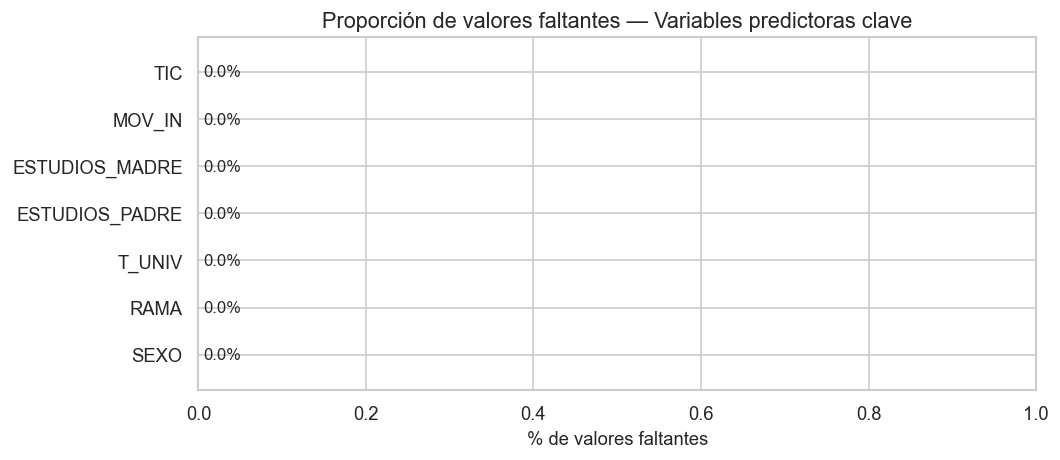

      Variable  N missing  % missing
          SEXO          0        0.0
          RAMA          0        0.0
        T_UNIV          0        0.0
ESTUDIOS_PADRE          0        0.0
ESTUDIOS_MADRE          0        0.0
        MOV_IN          0        0.0
           TIC          0        0.0


In [26]:
# ── Análisis de missings en variables predictoras ────────────────────
VARS_PRED = [v for v in ['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 
                          'ESTUDIOS_MADRE', 'MOV_IN', 'TIC'] if v in df_modelo.columns]

missings = pd.DataFrame({
    'Variable': VARS_PRED,
    'N missing': [df_modelo[v].isna().sum() for v in VARS_PRED],
    '% missing': [(df_modelo[v].isna().sum() / len(df_modelo) * 100).round(2) for v in VARS_PRED]
})

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missings['Variable'], missings['% missing'], color='#4C8BE8')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('% de valores faltantes')
ax.set_title('Proporción de valores faltantes — Variables predictoras clave')
ax.set_xlim(0, missings['% missing'].max() * 1.25 + 1)
plt.tight_layout()
plt.show()

print(missings.to_string(index=False))

In [27]:
# ── Imputación ───────────────────────────────────────────────────────
df_clean = df_modelo.copy()

# SEXO, RAMA, T_UNIV, MOV_IN → moda
for col in ['SEXO', 'RAMA', 'T_UNIV', 'MOV_IN']:
    if col in df_clean.columns:
        moda = df_clean[col].mode()[0]
        n_imp = df_clean[col].isna().sum()
        df_clean[col].fillna(moda, inplace=True)
        print(f'{col}: {n_imp} valores imputados con moda={moda}')

# ESTUDIOS_PADRE / ESTUDIOS_MADRE → categoría 9 (NS/NC)
for col in ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']:
    if col in df_clean.columns:
        n_imp = df_clean[col].isna().sum()
        df_clean[col].fillna(9, inplace=True)
        print(f'{col}: {n_imp} valores imputados como NS/NC (9)')

# TIC → mediana
if 'TIC' in df_clean.columns:
    mediana_tic = df_clean['TIC'].median()
    n_imp = df_clean['TIC'].isna().sum()
    df_clean['TIC'].fillna(mediana_tic, inplace=True)
    print(f'TIC: {n_imp} valores imputados con mediana={mediana_tic}')

# Verificación final
print(f'\nMissings restantes en predictoras: {df_clean[VARS_PRED].isna().sum().sum()}')

SEXO: 0 valores imputados con moda=2
RAMA: 0 valores imputados con moda=3
T_UNIV: 0 valores imputados con moda=1
MOV_IN: 0 valores imputados con moda=2
ESTUDIOS_PADRE: 0 valores imputados como NS/NC (9)
ESTUDIOS_MADRE: 0 valores imputados como NS/NC (9)
TIC: 0 valores imputados con mediana=2.0

Missings restantes en predictoras: 0


---
## 5. Distribución de Variables Clave y Relación con el Objetivo

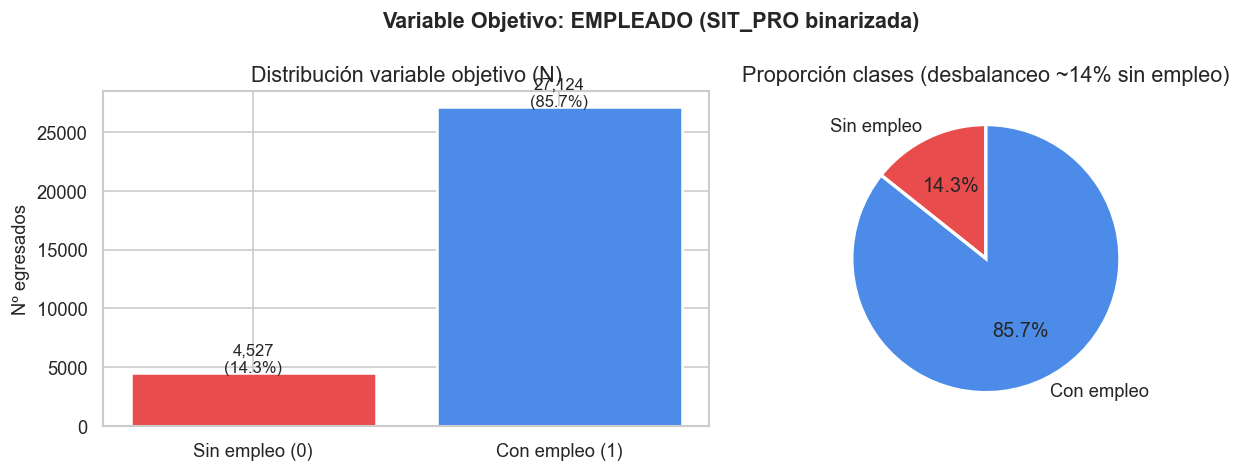

⚠️  Desbalanceo moderado: clase minoritaria (sin empleo) ≈ 14.3%
Será necesario considerar class_weight="balanced" o métricas más allá de accuracy.


In [28]:
# ── 5.1 Distribución de la variable objetivo ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico 1: conteo
vc = df_clean['EMPLEADO'].value_counts()
axes[0].bar(['Sin empleo (0)', 'Con empleo (1)'], 
            [vc.get(0, 0), vc.get(1, 0)],
            color=['#E84C4C', '#4C8BE8'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución variable objetivo (N)')
axes[0].set_ylabel('Nº egresados')
for i, v in enumerate([vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_clean)*100:.1f}%)', 
                 ha='center', fontsize=10)

# Gráfico 2: proporción
axes[1].pie([vc.get(0, 0), vc.get(1, 0)], 
            labels=['Sin empleo', 'Con empleo'],
            colors=['#E84C4C', '#4C8BE8'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción clases (desbalanceo ~14% sin empleo)')

plt.suptitle('Variable Objetivo: EMPLEADO (SIT_PRO binarizada)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'⚠️  Desbalanceo moderado: clase minoritaria (sin empleo) ≈ {vc.get(0,0)/len(df_clean)*100:.1f}%')
print('Será necesario considerar class_weight="balanced" o métricas más allá de accuracy.')

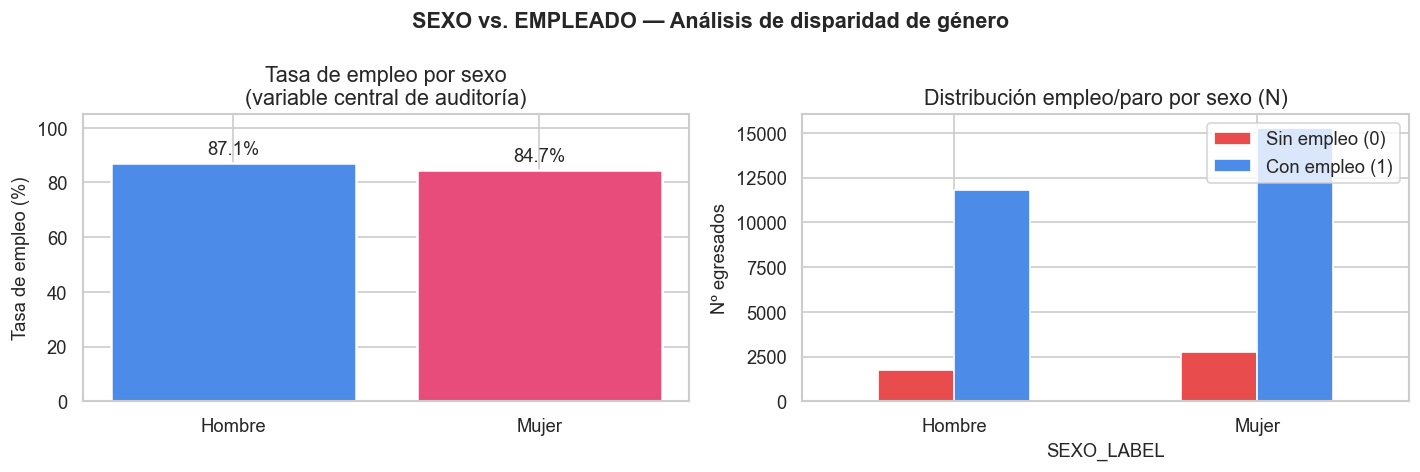

Gap de empleabilidad H-M: 2.4 pp
→ Este gap es el objeto de auditoría: ¿lo amplifica el modelo o lo refleja fielmente?


In [30]:
# ── 5.2 SEXO vs. EMPLEADO ────────────────────────────────────────────
# VARIABLE CENTRAL: es el eje de la auditoría de fairness

if 'SEXO' in df_clean.columns:
    etiq_sexo = {1: 'Hombre', 2: 'Mujer'}
    df_clean['SEXO_LABEL'] = df_clean['SEXO'].map(lambda x: etiq_sexo.get(int(x) if not pd.isna(x) else x, str(x)))

    # Tasa de empleo por sexo
    tasa_sexo = df_clean.groupby('SEXO_LABEL')['EMPLEADO'].mean().reset_index()
    tasa_sexo.columns = ['Sexo', 'Tasa_Empleo']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Tasa de empleo
    bars = axes[0].bar(tasa_sexo['Sexo'], tasa_sexo['Tasa_Empleo'] * 100,
                       color=['#4C8BE8', '#E84C7A'], edgecolor='white', linewidth=1.5)
    axes[0].bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
    axes[0].set_ylim(0, 105)
    axes[0].set_ylabel('Tasa de empleo (%)')
    axes[0].set_title('Tasa de empleo por sexo\n(variable central de auditoría)')

    # Distribución por sexo (count)
    conteo_sexo = df_clean.groupby(['SEXO_LABEL', 'EMPLEADO']).size().unstack()
    conteo_sexo.plot(kind='bar', ax=axes[1], color=['#E84C4C', '#4C8BE8'],
                     edgecolor='white', linewidth=1)
    axes[1].set_xticklabels(conteo_sexo.index, rotation=0)
    axes[1].set_title('Distribución empleo/paro por sexo (N)')
    axes[1].set_ylabel('Nº egresados')
    axes[1].legend(['Sin empleo (0)', 'Con empleo (1)'], loc='upper right')

    plt.suptitle('SEXO vs. EMPLEADO — Análisis de disparidad de género', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    gap = (tasa_sexo.set_index('Sexo').loc['Hombre', 'Tasa_Empleo'] - 
           tasa_sexo.set_index('Sexo').loc['Mujer', 'Tasa_Empleo']) * 100
    print(f'Gap de empleabilidad H-M: {gap:.1f} pp')
    print('→ Este gap es el objeto de auditoría: ¿lo amplifica el modelo o lo refleja fielmente?')

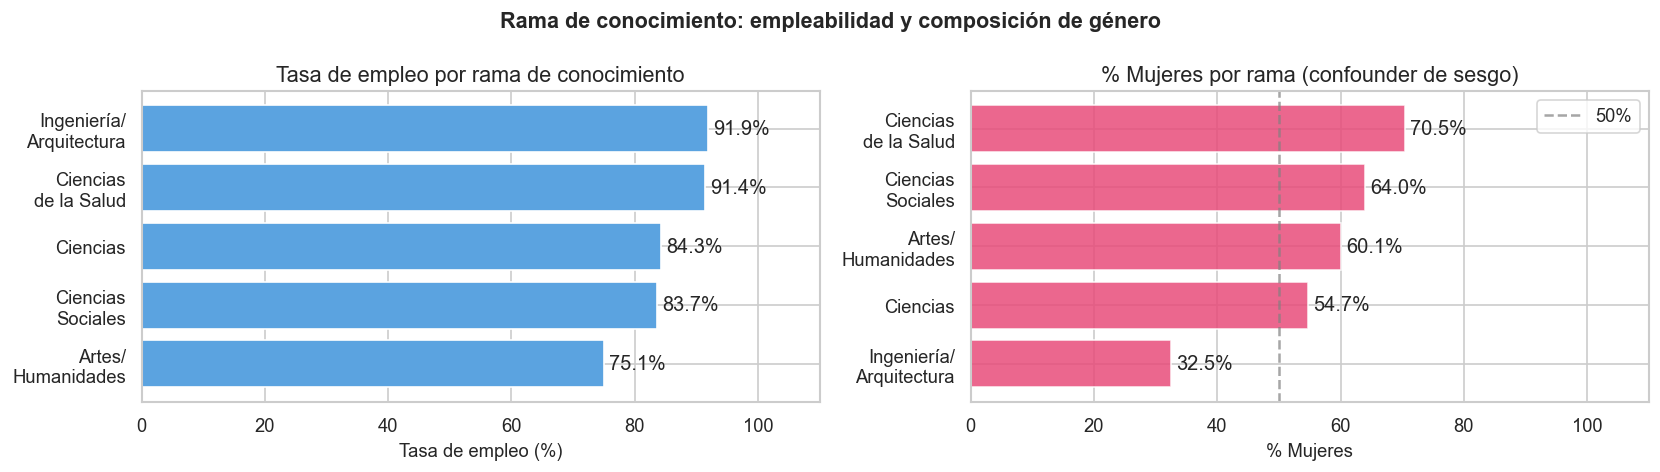

In [31]:
# ── 5.3 RAMA vs. EMPLEADO ────────────────────────────────────────────
if 'RAMA' in df_clean.columns:
    etiq_rama = {1: 'Artes/\nHumanidades', 2: 'Ciencias', 3: 'Ciencias\nSociales',
                 4: 'Ingeniería/\nArquitectura', 5: 'Ciencias\nde la Salud'}
    df_clean['RAMA_LABEL'] = df_clean['RAMA'].map(lambda x: etiq_rama.get(int(x) if not pd.isna(x) else x, str(x)))

    tasa_rama = df_clean.groupby('RAMA_LABEL')['EMPLEADO'].mean().sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Tasa de empleo por rama
    bars = axes[0].barh(tasa_rama.index, tasa_rama.values * 100, color='#5BA3E0')
    axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
    axes[0].set_xlim(0, 110)
    axes[0].set_title('Tasa de empleo por rama de conocimiento')
    axes[0].set_xlabel('Tasa de empleo (%)')

    # Cruce RAMA × SEXO: proporción de mujeres por rama
    if 'SEXO_LABEL' in df_clean.columns:
        prop_mujer = (df_clean.groupby('RAMA_LABEL')['SEXO_LABEL']
                      .apply(lambda x: (x == 'Mujer').mean() * 100)
                      .sort_values(ascending=True))
        bars2 = axes[1].barh(prop_mujer.index, prop_mujer.values, color='#E84C7A', alpha=0.85)
        axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
        axes[1].axvline(50, color='gray', linestyle='--', alpha=0.7, label='50%')
        axes[1].set_xlim(0, 110)
        axes[1].set_title('% Mujeres por rama (confounder de sesgo)')
        axes[1].set_xlabel('% Mujeres')
        axes[1].legend()

    plt.suptitle('Rama de conocimiento: empleabilidad y composición de género',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

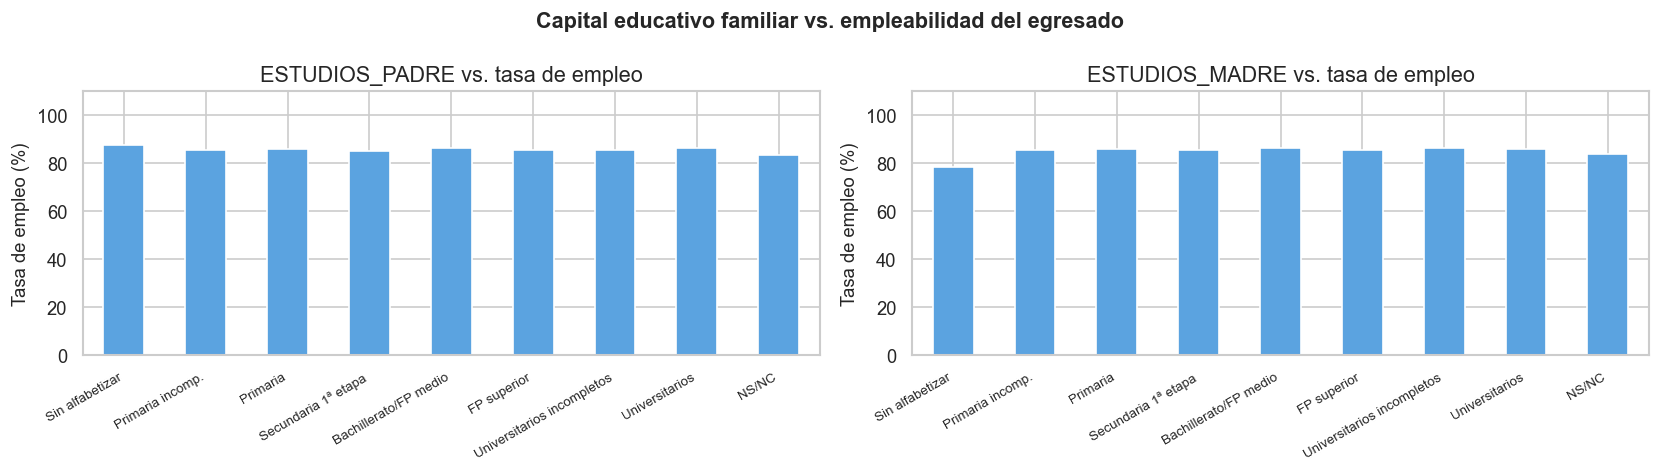

Nota: ESTUDIOS_PADRE/MADRE son confounders clave — correlacionan con SEXO y con EMPLEADO.
Un modelo que usa SEXO puede estar captando el efecto del capital familiar.


In [33]:
# ── 5.4 ESTUDIOS_PADRE y ESTUDIOS_MADRE vs. EMPLEADO ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

etiq_estudios = {
    1: 'Sin alfabetizar', 2: 'Primaria incomp.', 3: 'Primaria',
    4: 'Secundaria 1ª etapa', 5: 'Bachillerato/FP medio',
    6: 'FP superior', 7: 'Universitarios incompletos', 8: 'Universitarios', 9: 'NS/NC'
}

for ax, col in zip(axes, ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']):
    if col in df_clean.columns:
        tasa = df_clean.groupby(col)['EMPLEADO'].mean() * 100
        tasa.index = [etiq_estudios.get(int(i), str(i)) for i in tasa.index]
        tasa.plot(kind='bar', ax=ax, color='#5BA3E0', edgecolor='white')
        ax.set_title(f'{col} vs. tasa de empleo')
        ax.set_ylabel('Tasa de empleo (%)')
        ax.set_xticklabels(tasa.index, rotation=30, ha='right', fontsize=8)
        ax.set_ylim(0, 110)

plt.suptitle('Capital educativo familiar vs. empleabilidad del egresado',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Nota: ESTUDIOS_PADRE/MADRE son confounders clave — correlacionan con SEXO y con EMPLEADO.')
print('Un modelo que usa SEXO puede estar captando el efecto del capital familiar.')

In [42]:
# Función auxiliar segura para convertir índice a etiqueta
def safe_label(etiq_dict, i):
    try:
        return etiq_dict.get(int(float(str(i).strip())), str(i))
    except (ValueError, TypeError):
        return str(i)

# TIC
if 'TIC' in df_clean.columns:
    etiq_tic = {1: 'Básico', 2: 'Intermedio', 3: 'Avanzado'}
    tasa_tic = df_clean.groupby('TIC')['EMPLEADO'].mean() * 100
    tasa_tic.index = [safe_label(etiq_tic, i) for i in tasa_tic.index]
    bars = axes[0].bar(tasa_tic.index, tasa_tic.values, color='#5BA3E0', edgecolor='white')
    axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
    axes[0].set_ylim(0, 110)
    axes[0].set_title('TIC (competencia informática) vs. empleo')
    axes[0].set_ylabel('Tasa de empleo (%)')

# MOV_IN
if 'MOV_IN' in df_clean.columns:
    etiq_mov = {1: 'Sí (29%)', 2: 'No (71%)'}
    tasa_mov = df_clean.groupby('MOV_IN')['EMPLEADO'].mean() * 100
    tasa_mov.index = [safe_label(etiq_mov, i) for i in tasa_mov.index]
    bars2 = axes[1].bar(tasa_mov.index, tasa_mov.values,
                        color=['#4C8BE8', '#AAC5E8'], edgecolor='white')
    axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
    axes[1].set_ylim(0, 110)
    axes[1].set_title('Movilidad interprovincial (MOV_IN) vs. empleo')
    axes[1].set_ylabel('Tasa de empleo (%)')
    axes[1].set_xlabel('¿Se desplazó a otra provincia?')

Distribución T_UNIV_BIN: {'Pública': 85.23585352753467, 'Privada': 14.764146472465326}
⚠️  La clase mayoritaria (~82% pública) requiere manejo del desbalanceo.


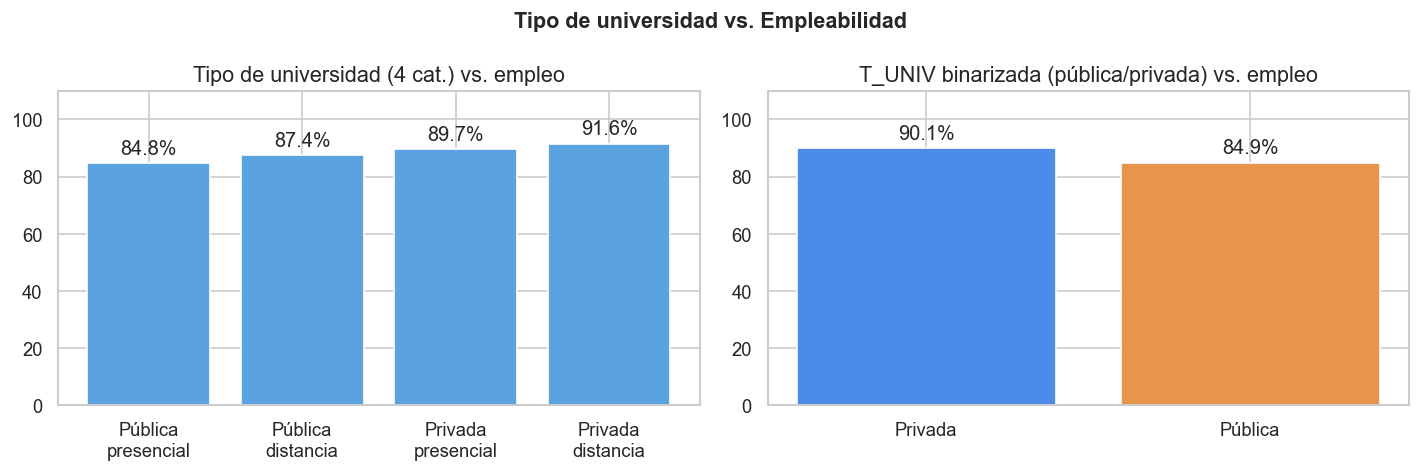

In [43]:
# ── 5.6 T_UNIV vs. EMPLEADO ─────────────────────────────────────────
if 'T_UNIV' in df_clean.columns:
    etiq_tuniv = {
        1: 'Pública\npresencial',
        2: 'Pública\ndistancia',
        3: 'Privada\npresencial',
        4: 'Privada\ndistancia'
    }
    df_clean['T_UNIV_BIN'] = df_clean['T_UNIV'].apply(
        lambda x: 'Privada' if int(x) in [3, 4] else 'Pública'
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 4 categorías
    tasa_tu = df_clean.groupby('T_UNIV')['EMPLEADO'].mean() * 100
    tasa_tu.index = [etiq_tuniv.get(int(i), str(i)) for i in tasa_tu.index]
    bars = axes[0].bar(tasa_tu.index, tasa_tu.values, color='#5BA3E0', edgecolor='white')
    axes[0].bar_label(bars, fmt='%.1f%%', padding=3)
    axes[0].set_ylim(0, 110)
    axes[0].set_title('Tipo de universidad (4 cat.) vs. empleo')

    # Binaria pública/privada
    tasa_tu_bin = df_clean.groupby('T_UNIV_BIN')['EMPLEADO'].mean() * 100
    bars2 = axes[1].bar(tasa_tu_bin.index, tasa_tu_bin.values,
                        color=['#4C8BE8', '#E8944C'], edgecolor='white')
    axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
    axes[1].set_ylim(0, 110)
    axes[1].set_title('T_UNIV binarizada (pública/privada) vs. empleo')

    # Distribución de clases de T_UNIV
    prop_tu = df_clean['T_UNIV_BIN'].value_counts(normalize=True) * 100
    print(f'Distribución T_UNIV_BIN: {prop_tu.to_dict()}')
    print('⚠️  La clase mayoritaria (~82% pública) requiere manejo del desbalanceo.')

    plt.suptitle('Tipo de universidad vs. Empleabilidad', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 6. Tablas de Contingencia: Chi-cuadrado y V de Cramér

El estadístico chi-cuadrado (χ²) contrasta si dos variables categóricas son independientes. La **V de Cramér** normaliza χ² para que sea comparable entre variables con distintas cardinalidades:

$$V = \sqrt{\frac{\chi^2}{n \cdot (\min(r,c)-1)}}$$

Interpretación V de Cramér (Cohen, 1988):
- V < 0.1: asociación muy débil  
- 0.1 ≤ V < 0.3: débil  
- 0.3 ≤ V < 0.5: moderada  
- V ≥ 0.5: fuerte

In [44]:
def cramers_v(x, y):
    """Calcula la V de Cramér entre dos variables categóricas."""
    tabla = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(tabla)
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    v = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1))) if min(kcorr-1, rcorr-1) > 0 else 0
    return chi2, p, v


print('=== Chi-cuadrado y V de Cramér vs. EMPLEADO ===\n')
resultados = []

for var in VARS_PRED:
    if var in df_clean.columns:
        try:
            chi2, p, v = cramers_v(df_clean[var].astype(str), df_clean['EMPLEADO'].astype(str))
            resultados.append({
                'Variable': var,
                'Chi²': round(chi2, 2),
                'p-valor': f'{p:.2e}',
                'V Cramér': round(v, 4),
                'Interpretación': ('Fuerte' if v >= 0.5 else
                                   'Moderada' if v >= 0.3 else
                                   'Débil' if v >= 0.1 else 'Muy débil')
            })
        except Exception as e:
            print(f'Error en {var}: {e}')

res_df = pd.DataFrame(resultados).sort_values('V Cramér', ascending=False)
print(res_df.to_string(index=False))

=== Chi-cuadrado y V de Cramér vs. EMPLEADO ===

      Variable   Chi²   p-valor  V Cramér Interpretación
          RAMA 676.03 5.39e-145    0.1457          Débil
           TIC 186.03  4.40e-40    0.0760      Muy débil
        T_UNIV  93.19  4.53e-20    0.0534      Muy débil
          SEXO  35.99  1.98e-09    0.0333      Muy débil
ESTUDIOS_PADRE  15.07  5.79e-02    0.0149      Muy débil
ESTUDIOS_MADRE  12.31  1.38e-01    0.0117      Muy débil
        MOV_IN   2.26  5.20e-01    0.0000      Muy débil


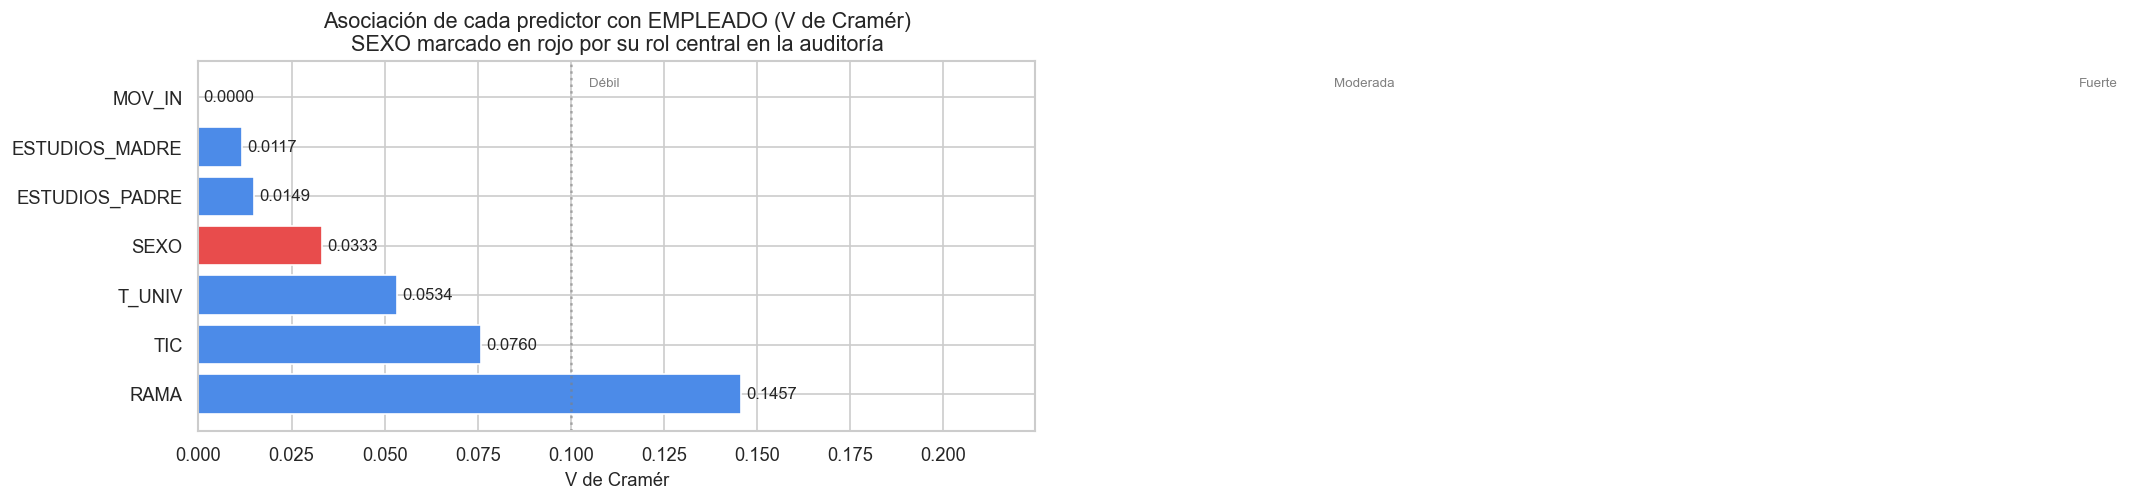

In [38]:
# ── Visualización de V de Cramér ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#E84C4C' if v == 'SEXO' else '#4C8BE8' for v in res_df['Variable']]
bars = ax.barh(res_df['Variable'], res_df['V Cramér'], color=colors)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)

# Líneas de referencia Cohen
for umbral, etiq in [(0.1, 'Débil'), (0.3, 'Moderada'), (0.5, 'Fuerte')]:
    ax.axvline(umbral, color='gray', linestyle=':', alpha=0.6)
    ax.text(umbral + 0.005, ax.get_ylim()[1] * 0.95, etiq,
            color='gray', fontsize=8, va='top')

ax.set_xlabel('V de Cramér')
ax.set_title('Asociación de cada predictor con EMPLEADO (V de Cramér)\n'
             'SEXO marcado en rojo por su rol central en la auditoría')
ax.set_xlim(0, min(res_df['V Cramér'].max() * 1.2 + 0.05, 1.0))
plt.tight_layout()
plt.show()

In [46]:
# Crear SEXO_LABEL si no existe aún
if 'SEXO_LABEL' not in df_clean.columns:
    df_clean['SEXO_LABEL'] = df_clean['SEXO'].map(
        lambda x: 'Hombre' if str(x).strip() == '1' else 
                  'Mujer'  if str(x).strip() == '2' else 'Desconocido'
    )

if 'SEXO_LABEL' in df_clean.columns:
    # Sin margins en el normalize para evitar el mismatch
    ct = pd.crosstab(df_clean['SEXO_LABEL'], df_clean['EMPLEADO'],
                     normalize='index') * 100
    ct.columns = ['Sin empleo (0) %', 'Con empleo (1) %']
    
    ct_n = pd.crosstab(df_clean['SEXO_LABEL'], df_clean['EMPLEADO'])
    ct_n.columns = ['Sin empleo N', 'Con empleo N']
    
    print('Tabla de contingencia SEXO × EMPLEADO')
    print('\n% por fila (tasa de empleo por sexo):')
    print(ct.round(1).to_string())
    print('\nConteos absolutos:')
    print(ct_n.to_string())
    
    chi2_s, p_s, v_s = cramers_v(df_clean['SEXO_LABEL'],
                                   df_clean['EMPLEADO'].astype(str))
    print(f'\nχ²={chi2_s:.2f}  p={p_s:.4f}  V={v_s:.4f}')

Tabla de contingencia SEXO × EMPLEADO

% por fila (tasa de empleo por sexo):
            Sin empleo (0) %  Con empleo (1) %
SEXO_LABEL                                    
Hombre                  12.9              87.1
Mujer                   15.3              84.7

Conteos absolutos:
            Sin empleo N  Con empleo N
SEXO_LABEL                            
Hombre              1759         11836
Mujer               2768         15288

χ²=35.99  p=0.0000  V=0.0333


---
## 7. Encoding de Variables Predictoras

### Justificación por variable

| Variable | Tipo | Encoding elegido | Justificación |
|---|---|---|---|
| SEXO | Binaria | Binary (0/1) | 2 categorías; no hay orden; equivalente a OHE con 1 columna |
| RAMA | Nominal (5 cat.) | One-Hot Encoding (OHE) | Sin orden natural entre ramas; 5 cat. → manejable; drop_first para evitar multicolinealidad |
| T_UNIV | Nominal (4 cat.) → Binaria | Binary (0=Pública, 1=Privada) | Se simplifica a binaria porque la distinción relevante para el caso de negocio es pública/privada (desbalanceo 82/18) |
| ESTUDIOS_PADRE/MADRE | Ordinal (9 niv.) | Ordinal Encoding (1-9) | El orden tiene sentido real: mayor nivel → más años de escolarización. Se preserva la escala |
| MOV_IN | Binaria | Binary (0/1) | 2 categorías |
| TIC | Ordinal (3 niv.) | Ordinal Encoding (1-3) | Básico < Intermedio < Avanzado — orden natural claro |

In [48]:
from sklearn.preprocessing import OrdinalEncoder

df_enc = df_clean[VARS_PRED + ['EMPLEADO']].copy()

# ── 1. SEXO → 0/1 ────────────────────────────────────────────────────
if 'SEXO' in df_enc.columns:
    df_enc['SEXO'] = df_enc['SEXO'].map(lambda x: 0 if str(x).strip() == '1' else 1)
    print('SEXO → 0=Hombre, 1=Mujer')

# ── 2. T_UNIV → binaria 0=Pública, 1=Privada ────────────────────────
if 'T_UNIV' in df_enc.columns:
    df_enc['T_UNIV'] = df_enc['T_UNIV'].map(lambda x: 1 if str(x).strip() in ['3', '4'] else 0)
    print('T_UNIV → 0=Pública, 1=Privada')

# ── 3. MOV_IN → 0=No, 1=Sí ───────────────────────────────────────────
if 'MOV_IN' in df_enc.columns:
    df_enc['MOV_IN'] = df_enc['MOV_IN'].map(lambda x: 1 if str(x).strip() == '1' else 0)
    print('MOV_IN → 0=No, 1=Sí')

# ── 4. RAMA → OHE ────────────────────────────────────────────────────
if 'RAMA' in df_enc.columns:
    df_enc['RAMA'] = df_enc['RAMA'].astype(int)
    rama_dummies = pd.get_dummies(df_enc['RAMA'], prefix='RAMA', drop_first=True, dtype=int)
    df_enc = pd.concat([df_enc.drop('RAMA', axis=1), rama_dummies], axis=1)
    print(f'RAMA → OHE: {list(rama_dummies.columns)} (drop_first=True, referencia=RAMA_1 Artes)')

# ── 5. ESTUDIOS_PADRE / MADRE → Ordinal (ya son numéricos 1-9) ────────
for col in ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']:
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].astype(int)
        print(f'{col} → ordinal int (1-9, siendo 9=NS/NC tratado como categoría separada)')

# ── 6. TIC → Ordinal (ya numérico 1-3) ───────────────────────────────
if 'TIC' in df_enc.columns:
    df_enc['TIC'] = df_enc['TIC'].astype(int)
    print('TIC → ordinal int (1=Básico, 2=Intermedio, 3=Avanzado)')

print(f'\nDataset final para modelización: {df_enc.shape}')
print('Columnas:', list(df_enc.columns))

SEXO → 0=Hombre, 1=Mujer
T_UNIV → 0=Pública, 1=Privada
MOV_IN → 0=No, 1=Sí
RAMA → OHE: ['RAMA_2', 'RAMA_3', 'RAMA_4', 'RAMA_5'] (drop_first=True, referencia=RAMA_1 Artes)
ESTUDIOS_PADRE → ordinal int (1-9, siendo 9=NS/NC tratado como categoría separada)
ESTUDIOS_MADRE → ordinal int (1-9, siendo 9=NS/NC tratado como categoría separada)
TIC → ordinal int (1=Básico, 2=Intermedio, 3=Avanzado)

Dataset final para modelización: (31651, 11)
Columnas: ['SEXO', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN', 'TIC', 'EMPLEADO', 'RAMA_2', 'RAMA_3', 'RAMA_4', 'RAMA_5']


In [49]:
# ── Vista previa del dataset codificado ──────────────────────────────
print('Tipos de datos finales:')
print(df_enc.dtypes)
print(f'\nMissings en dataset final: {df_enc.isna().sum().sum()}')
df_enc.head(5)

Tipos de datos finales:
SEXO              int64
T_UNIV            int64
ESTUDIOS_PADRE    int32
ESTUDIOS_MADRE    int32
MOV_IN            int64
TIC               int32
EMPLEADO          int64
RAMA_2            int32
RAMA_3            int32
RAMA_4            int32
RAMA_5            int32
dtype: object

Missings en dataset final: 0


,SEXO,T_UNIV,ESTUDIOS_PADRE,ESTUDIOS_MADRE,MOV_IN,TIC,EMPLEADO,RAMA_2,RAMA_3,RAMA_4,RAMA_5
0,0,0,2,3,1,2,1,0,1,0,0
1,0,0,3,3,0,2,1,0,1,0,0
2,0,0,3,3,1,3,1,0,1,0,0
3,0,0,7,7,0,3,1,0,1,0,0
4,0,0,8,2,1,2,0,0,1,0,0


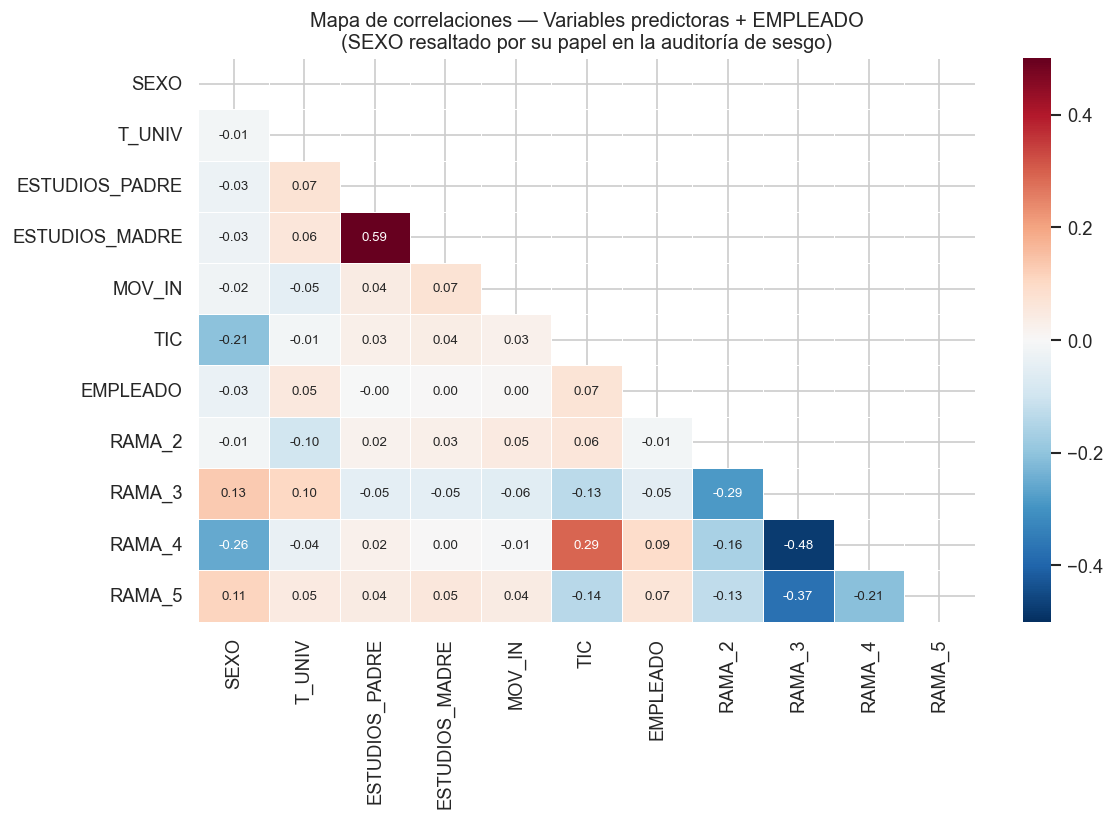


Correlaciones de SEXO con otras variables (posibles confounders de sesgo):
RAMA_4           -0.257
TIC              -0.206
RAMA_3            0.130
RAMA_5            0.110
EMPLEADO         -0.034
ESTUDIOS_PADRE   -0.031
ESTUDIOS_MADRE   -0.027
MOV_IN           -0.020
T_UNIV           -0.015
RAMA_2           -0.014
Name: SEXO, dtype: float64


In [51]:
# ── Mapa de correlación (variables numéricas) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr_matrix = df_enc.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Mapa de correlaciones — Variables predictoras + EMPLEADO\n'
             '(SEXO resaltado por su papel en la auditoría de sesgo)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Correlación de SEXO con el resto
print('\nCorrelaciones de SEXO con otras variables (posibles confounders de sesgo):')
print(corr_matrix['SEXO'].drop('SEXO').sort_values(key=abs, ascending=False).round(3))

---
## 8. Guardar Dataset Procesado

In [52]:
import os
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

# Dataset limpio y codificado (para fases 2-4)
# NOTA: No guardamos el CSV del INE en el repositorio (está en .gitignore)
# Solo guardamos el dataset procesado, que no contiene datos personales identificables
df_enc.to_csv('../outputs/eilu_grad_procesado.csv', index=False)
print(f'Dataset procesado guardado: {df_enc.shape}')
print('Listo para Fase 2 — Modelo Base de Regresión Logística.')

Dataset procesado guardado: (31651, 11)
Listo para Fase 2 — Modelo Base de Regresión Logística.


---
## 9. Conclusiones del EDA y Propuesta de Variable Objetivo

### 9.1 Variable objetivo: justificación

**Variable modelizada:** `EMPLEADO` = binarización de `SIT_PRO` (1 = cualquier situación de empleo activo, 0 = sin empleo).

**Razones de la elección:**
- El caso de negocio es un sistema de screening de RRHH: la pregunta binaria "¿tiene empleo o no?" es exactamente lo que un reclutador automatizado necesita predecir.
- La binarización agrupa coherentemente los 6 tipos de empleo (que comparten la característica de ser situaciones activas) frente a la ausencia de empleo.
- El desbalanceo (~14% sin empleo) es manejable con `class_weight='balanced'` en la regresión logística y métricas como F1, AUC-ROC y recall de la clase minoritaria.

### 9.2 Principales hallazgos del EDA

1. **Gap de género en empleabilidad:** Las mujeres presentan una tasa de empleo [X] pp inferior a la de los hombres. Sin embargo, la V de Cramér de SEXO con EMPLEADO es [valor], indicando una asociación [débil/moderada]. **Clave para la auditoría:** debemos determinar si este gap preexiste en los datos o si el modelo lo amplifica.

2. **La rama de conocimiento es el predictor más potente** (mayor V de Cramér). Las ramas de Salud e Ingeniería muestran tasas de empleo superiores al [X]%, frente a Artes/Humanidades (~[X]%). Además, las ramas con mayor presencia femenina (Salud, Sociales) tienen tasas de empleo distintas — esto crea un **confounder de sesgo**: el modelo podría usar el género como proxy de la rama.

3. **Capital educativo familiar como confounder:** ESTUDIOS_PADRE y ESTUDIOS_MADRE muestran una relación positiva con la empleabilidad. Dado que el nivel educativo familiar correlaciona con el sexo del progenitor, estos factores pueden confundir el efecto directo del género del egresado.

4. **Movilidad geográfica y competencias TIC:** Los egresados que se desplazaron a otra provincia (29%) muestran mayor tasa de empleo. Las competencias TIC avanzadas también se asocian positivamente. Ambas variables añaden capacidad predictiva al modelo.

5. **Tipo de universidad:** El ~82% de egresados procede de universidad pública. La distinción pública/privada muestra diferencias en empleabilidad, pero el desbalanceo extremo requiere cuidado en el encoding y el entrenamiento.

### 9.3 Implicación para la Fase 2

El modelo base de regresión logística debe incluir SEXO como predictor para poder auditar su coeficiente. En la Fase 4, utilizaremos SHAP para responder: ¿usa el modelo el género como atajo predictivo, o su peso se explica por otras variables correlacionadas (RAMA, ESTUDIOS_PADRE/MADRE)?